# solving fits in folder

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ccdproc, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name=version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, astroquery, photutils, ysfitsutilpy, ysphotutilpy, ccdproc, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        #print(f"**** module {pkg} is not installed")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
    else: 
        print(f"**** module {pkg} is installed")

%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module astroquery is installed
**** module photutils is installed
**** module ysfitsutilpy is installed
**** module ysphotutilpy is installed
**** module ccdproc is installed
**** module version_information is installed
This notebook was generated at 2023-11-14 18:18:11 (대한민국 표준시 = GMT+0900) 


c:\Users\USER\anaconda3\envs\astro_Python_env\Lib\site-packages\ysphotutilpy\seputil.py:113: UserWarning: Package sep is not installed. Some functions will not work.
  warn("Package sep is not installed. Some functions will not work.")


0 Python     3.11.4 64bit [MSC v.1916 64 bit (AMD64)]
1 IPython    8.12.2
2 OS         Windows 10 10.0.22631 SP0
3 numpy      1.25.2
4 pandas     2.1.0
5 matplotlib 3.7.2
6 scipy      1.11.1
7 astropy    5.3
8 astroquery 0.4.6
9 photutils  1.9.0
10 ysfitsutilpy 0.2
11 ysphotutilpy 0.1.1
12 ccdproc    2.4.1
13 version_information 1.0.4


### import modules

In [2]:
from glob import glob
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.stats import sigma_clip
from ccdproc import combine, ccd_process, CCDData

from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u
from astropy.time import Time
from astropy.visualization import ZScaleInterval, ImageNormalize
from astropy.coordinates import SkyCoord, EarthLocation, AltAz

import ysfitsutilpy as yfu

from astroquery.imcce import Skybot
from astropy.time import Time

import _astro_utilities
import _Python_utilities

plt.rcParams.update({'figure.max_open_warning': 0})

In [3]:
#%%
#######################################################
# read all files in base directory for processing
BASEDIR = Path("/mnt/Rdata/OBS_data") 
DOINGDIR = Path(BASEDIR / "asteroid/RiLA600_STX-16803_-_1bin")
DOINGDIRs = sorted(_Python_utilities.getFullnameListOfallsubDirs(DOINGDIR))

print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))
#######################################################

len(DOINGDIRs):  168


In [4]:
remove = 'BIAS'
DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
remove = 'DARK'
DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
remove = 'FLAT'
DOINGDIRs = [x for x in DOINGDIRs if remove not in x]

#print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))
#######################################################

len(DOINGDIRs):  168


In [70]:
Suwon = location = EarthLocation(lon=127.005 * u.deg, lat=37.308889 * u.deg, height=101 * u.m) 

In [30]:
for DOINGDIR in DOINGDIRs[:1] :
    DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)

    DOINGDIR = DOINGDIR / _astro_utilities.reduced_dir2
    ASTRESULTDIR = DOINGDIR / "ASTResult"

    if not ASTRESULTDIR.exists():
        os.makedirs("{}".format(str(ASTRESULTDIR)))
        print("{} is created...".format(str(ASTRESULTDIR)))
    
    fits_in_dir = sorted(list(DOINGDIR.glob('*.fit*')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(fits_in_dir))

    if len(fits_in_dir) == 0 :
        print(f"There is no fits fils in {DOINGDIR}")
        pass
    else : 
        print(f"Starting: {str(DOINGDIR.parts[-1])}")

        summary = yfu.make_summary(DOINGDIR/"*.fit*")
        print("len(summary):", len(summary))
        print("summary:", summary)
        #print(summary["file"][0])
        df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
        df_light = df_light.reset_index(drop=True)
        print("df_light:\n{}".format(df_light))

DOINGDIR /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin
/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/ASTResult is created...
len(fits_in_dir) 40
Starting: reduced2
All 122 keywords (guessed from /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-17-21-48_60sec_RiLA600_STX-16803_-20c_1bin.fits) will be loaded.


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _ROTA1 not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-17-41-15_120sec_RiLA600_STX-16803_-20c_1bin.fits, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _ROTA2 not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-17-41-15_120sec_RiLA600_STX-16803_-20c_1bin.fits, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _RPIX1 not found for /mnt/Rdata/OBS_data/asteroid/RiL

len(summary): 40
summary:                                                  file  filesize  SIMPLE  \
0   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
1   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
2   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
3   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
4   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
5   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
6   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
7   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
8   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
9   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67406400    True   
10  /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67305600    True   
11  /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67305600    True   

/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _ROTA1 not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-18-39-12_120sec_RiLA600_STX-16803_-20c_1bin.fits, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _ROTA2 not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-18-39-12_120sec_RiLA600_STX-16803_-20c_1bin.fits, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _RPIX1 not found for /mnt/Rdata/OBS_data/asteroid/RiL

In [7]:
for _, row  in df_light.iterrows():
    fpath = Path(row["file"])
    hdul = fits.open(fpath)

    SOLVE, ASTAP, LOCAL = _astro_utilities.checkPSolve(fpath)
    print(SOLVE, ASTAP, LOCAL)
    
    if SOLVE :
        w = WCS(hdul[0].header)
        t_obs = Time(hdul[0].header["DATE-OBS"]) + hdul[0].header["EXPOSURE"] * u.s / 2  # middle of observation time

        cent_coord = yfu.center_radec(ccd_or_header=hdul[0].header, center_of_image=True)

True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True
True True True


In [11]:
#field = SkyCoord(0*u.deg, 0*u.deg)
#epoch = Time('2019-05-29 21:42', format='iso')
results_ast = Skybot.cone_search(cent_coord, 50*u.arcmin, t_obs)
results_ast.pprint(max_width=80) 

Number    Name            RA         ...      vy          vz       epoch  
                         deg         ...    AU / d      AU / d       d    
------ ---------- ------------------ ... ----------- ----------- ---------
    --  2017 KK14 29.455028749999997 ... 0.007012167 0.004386639 2460220.0
393701 2004 TK115 29.540466249999998 ... 0.010221356 0.005910071 2460220.0
198631  2005 AW51 29.417346249999994 ... 0.007934877 0.004153272 2460220.0
303481  2005 EH31  29.39374541666666 ... 0.007200073 0.006062353 2460220.0
    --  2016 CM88 29.534856249999997 ... 0.007100478 0.004787661 2460220.0
389452 2010 CA228 29.620583333333332 ... 0.006886947 0.005799374 2460220.0
472348    2015 BU  29.31338833333333 ... 0.008802897 0.004561601 2460220.0
    --  2014 RZ24 29.380194166666662 ... 0.009664116 0.004475937 2460220.0
 29972   Chriswan 29.434098333333328 ... 0.008210757 0.002103418 2460220.0
 83634 2001 SO324  29.68527083333333 ... 0.008625078 0.001691112 2460220.0
   ...        ...        

In [16]:
df_ast = results_ast.to_pandas()
df_ast[df_ast['V'] < 16]

,Number,Name,RA,DEC,Type,V,posunc,centerdist,RA_rate,DEC_rate,...,heliodist,alpha,elong,x,y,z,vx,vy,vz,epoch
34,2159,Kukkamaki,29.754782,15.484331,MB>Inner,15.5,0.021,1631.273,-32.0431,-7.539,...,2.461810,6.59,163.50,2.250031,0.909888,0.479165,-0.004947,0.008757,0.004348,2460220.0
102,135,Hertha,28.792072,14.825575,MB>Inner,11.0,0.030,2585.850,-34.2226,-9.005,...,2.103272,7.19,164.64,1.940727,0.701757,0.361446,-0.002875,0.011142,0.005314,2460220.0


In [19]:
#df_ast[df_ast['V'] < 16]['Number'][0]

In [24]:
#####################################################################
# Our object (will be queried to JPL HORIZONS)
OBJID = '2159' # Kleopatra

# Observed location
LOCATION = dict(lon=127.005, lat=37.308889, elevation=130)
observatory_code = "P64"

from astropy import units as u
# It is used as a rough estimate, so no need to be accurate:
PIX2ARCSEC = 0.62*u.arcsec

# Used for any `astropy.SkyCoord` object:
SKYC_KW = dict(unit=u.deg, frame='icrs')

In [25]:
from astropy import units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astroquery.jplhorizons import Horizons

# D.2. Find the observation time and exposure time to set the obs time
t_start = Time(hdul[0].header['DATE-OBS'], format='isot')
t_expos = hdul[0].header['EXPTIME'] * u.s
t_middle = t_start + t_expos / 2 # start time + 0.5 * exposure time

print(f"t_start: {t_start}, t_expos: {t_expos}, t_middle: {t_middle}")

t_start: 2023-10-10T18:41:24.109, t_expos: 180.0 s, t_middle: 2023-10-10T18:42:54.109


In [26]:
# D.3. Query the ephemerides of this target! See below why I used '900486', not '41P'.
obj = Horizons(id=OBJID, location=observatory_code, epochs=t_middle.jd)
obj_ephem = obj.ephemerides()

obj_ephem

targetname,datetime_str,datetime_jd,H,G,solar_presence,flags,RA,DEC,RA_app,DEC_app,RA_rate,DEC_rate,AZ,EL,AZ_rate,EL_rate,sat_X,sat_Y,sat_PANG,siderealtime,airmass,magextinct,V,surfbright,illumination,illum_defect,sat_sep,sat_vis,ang_width,PDObsLon,PDObsLat,PDSunLon,PDSunLat,SubSol_ang,SubSol_dist,NPole_ang,NPole_dist,EclLon,EclLat,r,r_rate,delta,delta_rate,lighttime,vel_sun,vel_obs,elong,elongFlag,alpha,lunar_elong,lunar_illum,sat_alpha,sunTargetPA,velocityPA,OrbPlaneAng,constellation,TDB-UT,ObsEclLon,ObsEclLat,NPole_RA,NPole_DEC,GlxLon,GlxLat,solartime,earth_lighttime,RA_3sigma,DEC_3sigma,SMAA_3sigma,SMIA_3sigma,Theta_3sigma,Area_3sigma,RSS_3sigma,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
---,---,d,mag,---,---,---,deg,deg,deg,deg,arcsec / h,arcsec / h,deg,deg,arcsec / min,arcsec / min,arcsec,arcsec,deg,---,---,mag,mag,mag / arcsec2,%,arcsec,arcsec,---,arcsec,deg,deg,deg,deg,deg,arcsec,deg,arcsec,deg,deg,AU,km / s,AU,km / s,min,km / s,km / s,deg,---,deg,deg,%,deg,deg,deg,deg,---,s,deg,deg,deg,deg,deg,deg,---,min,arcsec,arcsec,arcsec,arcsec,deg,arcsec2,arcsec,km,km / s,Hz,Hz,s,deg,---,deg,deg,deg
str24,str24,float64,float64,float64,str1,str1,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str1,float64,int64,int64,int64,int64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str2,float64,float64,float64,float64,float64,float64,float64,str3,float64,float64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
2159 Kukkamaki (1941 UX),2023-Oct-10 18:42:54.109,2460228.279792928,11.99,0.15,,m,29.75418,15.48369,30.07985,15.60069,-33.0347,-7.69873,246.237385,50.962753,569.43,-657.45,-592652.72,80484.317,303.6,4.45605945,1.286,0.349,15.328,5.187,99.66916,3.5e-05,588578.1,*,0.010591,--,--,--,--,59.19,0.0,--,--,26.5996,1.8982,2.470283077704,-0.75377,1.49639718380371,-6.2215224,12.44515589,19.0004335,11.9702929,163.4939,/L,6.6002,120.4,13.6001,9.5857,239.104,247.413,-0.9387,Ari,69.182353,33.4154726,3.1369338,--,--,145.992015,-44.338309,3.3989422102,0.000354,0.035,0.014,0.037,0.00112,22.627,0.0001323,0.037,4.0297,2.1e-06,0.06,0.23,2.7e-05,275.3032,2.450736109,6.5948,29.8365,2.5206


In [27]:
# D.4. Get the WCS information and convert it to image XY coordinate
wcs = WCS(hdul[0].header)
print("wcs :", wcs)
print("type(wcs) :", type(wcs))
print("dir(wcs) :", dir(wcs))

wcs.pixel_n_dim

wcs : WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 29.4532027883  15.1059695247  
CRPIX : 2158.52029419  1961.64060783  
PC1_1 PC1_2  : 1.028973040558e-05  0.0001720616536662  
PC2_1 PC2_2  : -0.0001720732222427  1.033600565821e-05  
CDELT : 1.0  1.0  
NAXIS : 4096  4096
type(wcs) : <class 'astropy.wcs.wcs.WCS'>
dir(wcs) : ['__abstractmethods__', '__class__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__iter__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_all_pix2world', '_all_world2pix', '_array_converter', '_as_mpl_axes', '_denormalize_sky', '_det2im', '_fix_ctype', '_fix_scamp', '_get_components_and_classes', '_get_naxis', '_init_

/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/astropy/wcs/wcs.py:3064: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


2

In [28]:
obj_radec = SkyCoord(obj_ephem['RA'][0], obj_ephem['DEC'][0], unit=u.deg)
obj_imgxy = obj_radec.to_pixel(wcs=wcs)
cut = Cutout2D(hdul[0].data, obj_imgxy, (1000, 1000), wcs=wcs)

cut_hdu = fits.PrimaryHDU(data = cut.data,
                          header = hdul[0].header + cut.wcs.to_header())


In [29]:
import pandas as pd
df_eph = obj_ephem.to_pandas()
df_eph

,targetname,datetime_str,datetime_jd,H,G,solar_presence,flags,RA,DEC,RA_app,...,r_3sigma,r_rate_3sigma,SBand_3sigma,XBand_3sigma,DoppDelay_3sigma,true_anom,hour_angle,alpha_true,PABLon,PABLat
0,2159 Kukkamaki (1941 UX),2023-Oct-10 18:42:54.109,2.460228e+06,11.99,0.15,,m,29.75418,15.48369,30.07985,...,4.0297,0.000002,0.06,0.23,0.000027,275.3032,2.450736,6.5948,29.8365,2.5206


In [31]:
df_eph.to_csv(f"{ASTRESULTDIR/fpath.stem}_AST.csv")

In [32]:
for _, row in df_eph.iterrows():
    print(#"row['targetname'] :", row['targetname'],
          #"row['datetime_str'] :", row['datetime_str'],
          #"row['datetime_jd'] :", row['datetime_jd'],
          "row['RA'] :", row['RA'],
          "row['DEC'] :", row['DEC'],
          )

row['RA'] : 29.75418 row['DEC'] : 15.48369


In [33]:
# =============================================================================
# E. Plot cutout image
# =============================================================================

from matplotlib import pyplot as plt
from astropy.visualization import ZScaleInterval, ImageNormalize

def znorm(image, **kwargs):
    return ImageNormalize(image, interval=ZScaleInterval(**kwargs))

def zimshow(ax, image, **kwargs):
    return ax.imshow(image, norm=znorm(image, **kwargs), origin='lower')


fpath: /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-18-41-24_180sec_RiLA600_STX-16803_-20c_1bin.fits


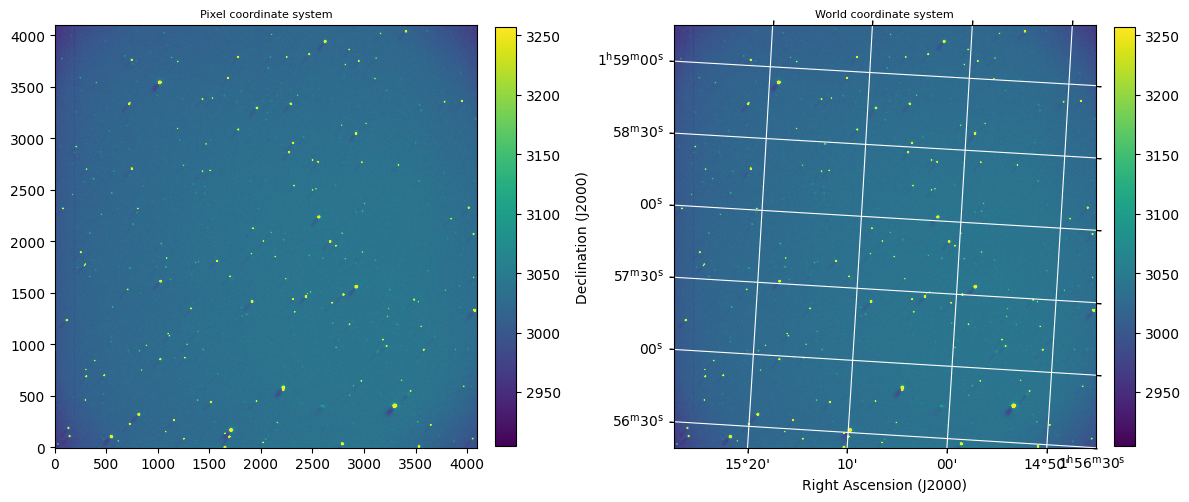

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import (MinMaxInterval, SqrtStretch,
                                   ImageNormalize)

print(f"fpath: {fpath}")
hdul = fits.open(str(fpath), unit="adu")

wcs = WCS(hdul[0].header)

fig_set = plt.figure(figsize=(12, 24))

ax1 = plt.subplot2grid((1,2), (0,0),
                       fig=fig_set)

im1 = zimshow(ax1, hdul[0].data,
            )

ax1.set_title('Pixel coordinate system', fontsize=8)

ax2 = plt.subplot2grid((1,2), (0,1),
                    projection=wcs,
                    fig=fig_set)

im2 = zimshow(ax2, hdul[0].data,
            )
ax2.set_title('World coordinate system', fontsize=8)

ax2.coords.grid(True, color='white', ls='solid')
ax2.coords['ra'].set_axislabel('Right Ascension (J2000)')
ax2.coords['ra'].set_ticklabel_position('bl')
ax2.coords['dec'].set_axislabel('Declination (J2000)')
ax2.coords['dec'].set_ticklabel_position('bl')

plt.colorbar(im1, ax = ax1, fraction=0.0455, pad=0.04)
plt.colorbar(im2, ax = ax2, fraction=0.0455, pad=0.04)
plt.tight_layout()

In [35]:
pos_targ_inits = []
for i, row in df_eph.iterrows():
    # print("row['targetname'] :", row['targetname'],
    #       "row['datetime_str'] :", row['datetime_str'],
    #       "row['datetime_jd'] :", row['datetime_jd'],
    #       "row['RA'] :", row['RA'],
    #       "row['DEC'] :", row['DEC'],
    #       )
    wcs = WCS(hdul[0].header)
    pos_targ_init = SkyCoord(row['RA'], row["DEC"],
						**SKYC_KW).to_pixel(wcs)
    #print("type(pos_targ_init) :", type(pos_targ_init))
    pos_targ_inits.append(pos_targ_init)
#print(pos_targ_inits)

df_eph['pos_targ_init'] = pos_targ_inits
print("df_eph['pos_targ_init'] :", df_eph['pos_targ_init'])

df_eph['pos_targ_init'] : 0    (69.00878326011565, 3768.818395513428)
Name: pos_targ_init, dtype: object


fpath: /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin/reduced2/120LACHESIS_LIGHT_R_2023-10-10-18-41-24_180sec_RiLA600_STX-16803_-20c_1bin.fits


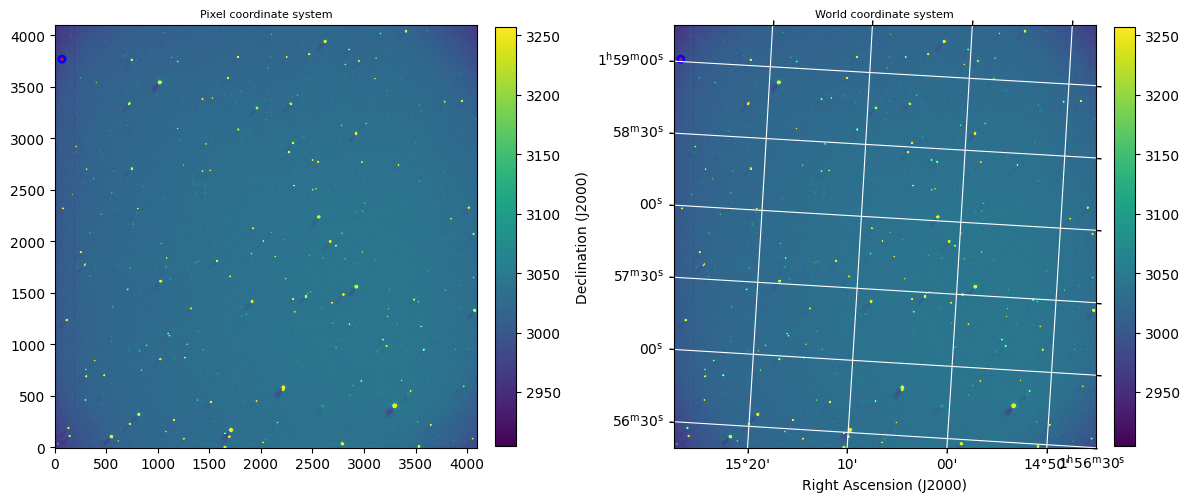

In [36]:
#######################################################
# Initial guess of FWHM in pixel
FWHM_INIT = 6

# Photometry parameters
R_AP = 1.5*FWHM_INIT # Aperture radius
R_IN = 4*FWHM_INIT   # Inner radius of annulus
R_OUT = 6*FWHM_INIT  # Outer radius of annulus
#######################################################

import numpy as np
import matplotlib.pyplot as plt
from photutils.aperture import CircularAperture as CAp
from photutils.aperture import CircularAnnulus as CAn

targ_ap = CAp(df_eph['pos_targ_init'][0],
        r=R_AP)
targ_an = CAn(df_eph['pos_targ_init'][0],
        r_in=R_IN,
        r_out=R_OUT)


print(f"fpath: {fpath}")
hdul = fits.open(str(fpath), unit="adu")

wcs = WCS(hdul[0].header)

fig_set = plt.figure(figsize=(12, 24))

ax1 = plt.subplot2grid((1,2), (0,0),
                       fig=fig_set)

im1 = zimshow(ax1, hdul[0].data,
            )

targ_ap.plot(ax1, color="r")
targ_an.plot(ax1, color="b")
ax1.set_title('Pixel coordinate system', fontsize=8)
plt.colorbar(im1, ax = ax1, fraction=0.0455, pad=0.04)

ax2 = plt.subplot2grid((1,2), (0,1),
                    projection=wcs,
                    fig=fig_set)

im2 = zimshow(ax2, hdul[0].data,
            )

targ_ap.plot(ax2, color="r")
targ_an.plot(ax2, color="b")

ax2.set_title('World coordinate system', fontsize=8)

ax2.coords.grid(True, color='white', ls='solid')
ax2.coords['ra'].set_axislabel('Right Ascension (J2000)')
ax2.coords['ra'].set_ticklabel_position('bl')
ax2.coords['dec'].set_axislabel('Declination (J2000)')
ax2.coords['dec'].set_ticklabel_position('bl')

plt.colorbar(im2, ax = ax2, fraction=0.0455, pad=0.04)
plt.tight_layout()

plt.show()

In [37]:
from astropy.nddata import Cutout2D
from astropy.stats import sigma_clip, sigma_clipped_stats
from photutils.centroids import centroid_com

#1. cut asteroia area
cutsizes = 49
cut_hdu = Cutout2D(
            data = hdul[0].data,
            position = (df_eph['pos_targ_init'][0]),
            size=(cutsizes, cutsizes) #cut ccd
            )
avg, med, std = sigma_clipped_stats(cut_hdu.data)  # by default, 3-sigma 5-iteration.


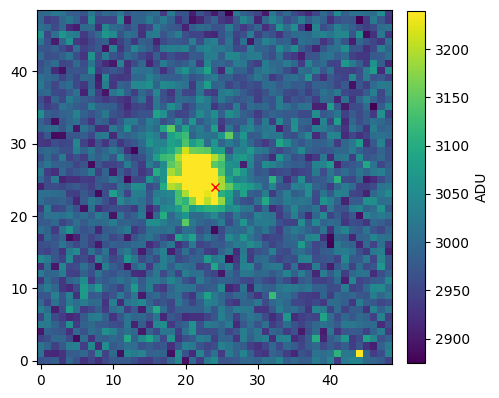

Image size is:  (49, 49)


In [38]:
fig, ax = plt.subplots(1,1, figsize=(5,5))
obj_im = zimshow(ax, cut_hdu.data)
plt.plot(round(cutsizes/2), round(cutsizes/2), 'rx')

plt.colorbar(obj_im, label="ADU", fraction=0.0455, pad=0.04)
plt.show()
print("Image size is: ", cut_hdu.data.shape)

In [39]:
#2. Get center dx, dy
thresh_3sig = med + 3 * std
mask_3sig = (cut_hdu.data < thresh_3sig)
center = centroid_com(
            data = cut_hdu.data,
            mask = mask_3sig
            )

centerdx = round(cutsizes/2)-center[0]
centerdy = round(cutsizes/2)-center[1]

print("type(center):", type(center))
print("center:", center)
print("center dx, dy:", centerdx, centerdy)

type(center): <class 'numpy.ndarray'>
center: [21.96072845 25.00987195]
center dx, dy: 2.039271549234819 -1.0098719542657157


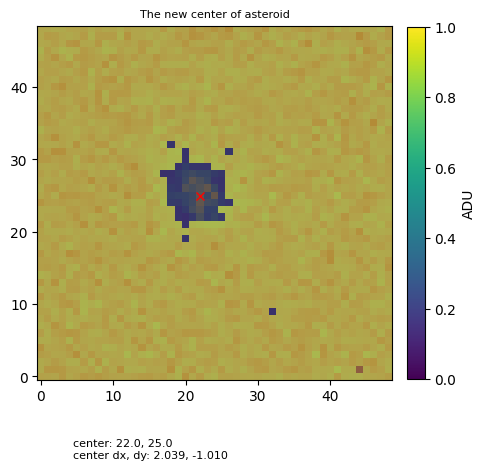

In [40]:
fig, ax = plt.subplots(1,1, figsize=(5,5))

plt.title(f'The new center of asteroid', fontsize=8)
obj_im = plt.imshow(mask_3sig.astype(int),
    origin="lower")
plt.imshow(cut_hdu.data,
        alpha=0.4,
        origin="lower")
plt.plot(*center, 'rx')
plt.annotate(f"center: {center[0]:.01f}, {center[1]:.1f}\ncenter dx, dy: {centerdx:.03f}, {centerdy:.03f}",
    xy=(0, 0), xytext=(0.1, -0.22),
    xycoords='axes fraction',
    fontsize=8)
plt.colorbar(obj_im,
            label="ADU",
            fraction=0.0455, pad=0.04)

In [41]:
print(df_eph['pos_targ_init'])
pos_targ_from_fits = (df_eph['pos_targ_init'][0][0] - centerdx, df_eph['pos_targ_init'][0][1] - centerdy )
print(pos_targ_from_fits)

0    (69.00878326011565, 3768.818395513428)
Name: pos_targ_init, dtype: object
(66.96951171088082, 3769.828267467694)
